# LOSO Training — MultiBranch CNN

Leave-One-Subject-Out cross-validation for FOG detection.

**Before running:** fill in the `DEVICE_MAPPING` dictionary in cell 2 with the correct device → body part mapping for each subject.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

## 2. Configuration

### ⚠️ Fill in DEVICE_MAPPING before running

For each subject, specify which device corresponds to `ankle_l`, `ankle_r`, and `back`.
Use `None` if a device was not functioning for that subject.

In [2]:
DATA_DIR = Path('/Users/zoemonnard/Library/CloudStorage/OneDrive-epfl.ch/fog_labeled_data/combined')

# ── FILL THIS IN ──────────────────────────────────────────────────
DEVICE_MAPPING = {
    'FOG002': {'ankle_l': 'dev5', 'ankle_r': 'dev2', 'back': 'dev3'},
    'FOG003': {'ankle_l': 'dev7', 'ankle_r': 'dev2', 'back': 'dev3'},
    'FOG004': {'ankle_l': 'dev7', 'ankle_r': 'dev2', 'back': 'dev3'},
    'FOG005': {'ankle_l': 'dev3', 'ankle_r': 'dev2', 'back': 'dev7'},
    'FOG006': {'ankle_l': 'dev5', 'ankle_r': 'dev2', 'back': 'dev6'},
    'FOG009': {'ankle_l': 'dev7', 'ankle_r': 'dev2', 'back': 'dev3'},
    'FOG010': {'ankle_l': 'dev5', 'ankle_r': 'dev6', 'back': 'dev3'},
    'FOG011': {'ankle_l': 'dev2', 'ankle_r': 'dev3', 'back': 'dev7'},
    'FOG012': {'ankle_l': 'dev3', 'ankle_r': 'dev4', 'back': 'dev7'},
    'FOG013': {'ankle_l': 'dev5', 'ankle_r': 'dev2', 'back': 'dev7'},
    'FOG014': {'ankle_l': 'dev4', 'ankle_r': 'dev3', 'back': 'dev5'},
    'FOG015': {'ankle_l': 'dev3', 'ankle_r': 'dev4', 'back': 'dev1'},
    'FOG016': {'ankle_l': 'dev4', 'ankle_r': 'dev7', 'back': 'dev3'},
    'FOG017': {'ankle_l': 'dev5', 'ankle_r': 'dev4', 'back': 'dev3'},
}
# ─────────────────────────────────────────────────────────────────

# Task filter — set to None to use all tasks
TASKS_TO_INCLUDE = ['8_Shape_Circuit_1', 'Narrow_Corridor_1']  # ← change or set to None

TEST_SUBJECTS = ['FOG002', 'FOG003', 'FOG004', 'FOG006', 'FOG010',
                 'FOG011', 'FOG012', 'FOG013', 'FOG014', 'FOG015']
ALL_SUBJECTS  = list(DEVICE_MAPPING.keys())

# Segmentation
FS       = 100    # Hz
W_SEC    = 2.0    # window size in seconds
OVERLAP  = 0.75   # 75% overlap — matches original training, maximizes FOG windows
WIN_SIZE = int(W_SEC * FS)
STEP     = int(WIN_SIZE * (1 - OVERLAP))

# Training — matches original training setup
BATCH_SIZE   = 256
N_EPOCHS     = 50
LR           = 5e-4   # matches original
WEIGHT_DECAY = 0.0036  # matches original
PATIENCE     = 10      # early stopping patience

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Window: {WIN_SIZE} samples ({W_SEC}s @ {FS}Hz) | Step: {STEP} samples')


Device: cpu
Window: 200 samples (2.0s @ 100Hz) | Step: 50 samples


## 3. Model architecture

In [3]:
# ── Model configuration ───────────────────────────────────────
# INPUT_MODE controls which channels are used:
#   'acc'      : acceleration only  — ankles: 6ch, back: 3ch (total 9)
#   'quat'     : quaternions only   — ankles: 8ch, back: 4ch (total 12)
#   'acc_quat' : both combined      — ankles: 14ch, back: 7ch (total 21)
INPUT_MODE = 'acc'  # ← change here

INPUT_CONFIG = {
    'acc'     : {'ankle_ch': 6,  'back_ch': 3},
    'quat'    : {'ankle_ch': 8,  'back_ch': 4},
    'acc_quat': {'ankle_ch': 14, 'back_ch': 7},
}

class MultiBranchCNN(nn.Module):
    def __init__(self, ankle_ch=6, back_ch=3):
        super().__init__()
        self.ankle_branch = nn.Sequential(
            nn.Conv1d(ankle_ch, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(0.5),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.back_branch = nn.Sequential(
            nn.Conv1d(back_ch, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(0.5),
            nn.Conv1d(16, 64, kernel_size=3, padding=1),
            nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.32),
            nn.Linear(64, 1)
            # No Sigmoid — BCEWithLogitsLoss applies it internally
        )

    def forward(self, x):
        ankle_ch = self.ankle_branch[0].in_channels
        ankles = x[:, :ankle_ch, :]
        back   = x[:, ankle_ch:, :]
        feat_ankles = self.ankle_branch(ankles).view(x.size(0), -1)
        feat_back   = self.back_branch(back).view(x.size(0), -1)
        return self.classifier(torch.cat([feat_ankles, feat_back], dim=1))

cfg = INPUT_CONFIG[INPUT_MODE]
print(f'Input mode  : {INPUT_MODE}')
print(f'Ankle ch    : {cfg["ankle_ch"]} | Back ch: {cfg["back_ch"]}')
print(f'Total input : {cfg["ankle_ch"] + cfg["back_ch"]} channels')


Input mode  : acc
Ankle ch    : 6 | Back ch: 3
Total input : 9 channels


## 4. Data loading helpers

In [4]:
QUAT_COLS = ['quat_w', 'quat_x', 'quat_y', 'quat_z']
ACC_COLS  = ['acc_x', 'acc_y', 'acc_z']

def get_feature_cols():
    """Return feature column names based on INPUT_MODE."""
    if INPUT_MODE == 'acc':
        return [
            'ankleL_ax', 'ankleL_ay', 'ankleL_az',
            'ankleR_ax', 'ankleR_ay', 'ankleR_az',
            'back_ax',   'back_ay',   'back_az',
        ]
    elif INPUT_MODE == 'quat':
        return [
            'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
            'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
            'back_q0',   'back_q1',   'back_q2',   'back_q3',
        ]
    else:  # acc_quat
        return [
            'ankleL_ax', 'ankleL_ay', 'ankleL_az',
            'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
            'ankleR_ax', 'ankleR_ay', 'ankleR_az',
            'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
            'back_ax',   'back_ay',   'back_az',
            'back_q0',   'back_q1',   'back_q2',   'back_q3',
        ]


def load_subject(subject_id):
    mapping = DEVICE_MAPPING[subject_id]
    if any(v is None for v in mapping.values()):
        print(f'  [{subject_id}] skipped — device mapping not filled in')
        return None
    dfs = {}
    for role, dev in mapping.items():
        path = DATA_DIR / f'IMU_{dev}_{subject_id}_all_tasks.csv'
        if not path.exists():
            print(f'  [{subject_id}] skipped — {path.name} not found')
            return None
        dfs[role] = pd.read_csv(path)
    min_len = min(len(df) for df in dfs.values())
    for role in dfs:
        dfs[role] = dfs[role].iloc[:min_len].reset_index(drop=True)

    # Build combined DataFrame with all channels
    combined = pd.DataFrame({
        # Ankle L
        'ankleL_ax': dfs['ankle_l']['acc_x'].values,
        'ankleL_ay': dfs['ankle_l']['acc_y'].values,
        'ankleL_az': dfs['ankle_l']['acc_z'].values,
        'ankleL_q0': dfs['ankle_l']['quat_w'].values,
        'ankleL_q1': dfs['ankle_l']['quat_x'].values,
        'ankleL_q2': dfs['ankle_l']['quat_y'].values,
        'ankleL_q3': dfs['ankle_l']['quat_z'].values,
        # Ankle R
        'ankleR_ax': dfs['ankle_r']['acc_x'].values,
        'ankleR_ay': dfs['ankle_r']['acc_y'].values,
        'ankleR_az': dfs['ankle_r']['acc_z'].values,
        'ankleR_q0': dfs['ankle_r']['quat_w'].values,
        'ankleR_q1': dfs['ankle_r']['quat_x'].values,
        'ankleR_q2': dfs['ankle_r']['quat_y'].values,
        'ankleR_q3': dfs['ankle_r']['quat_z'].values,
        # Back
        'back_ax'  : dfs['back']['acc_x'].values,
        'back_ay'  : dfs['back']['acc_y'].values,
        'back_az'  : dfs['back']['acc_z'].values,
        'back_q0'  : dfs['back']['quat_w'].values,
        'back_q1'  : dfs['back']['quat_x'].values,
        'back_q2'  : dfs['back']['quat_y'].values,
        'back_q3'  : dfs['back']['quat_z'].values,
        # Labels
        'fog'      : dfs['ankle_l']['fog_label'].values,
        'subject'  : subject_id,
        'task_name': dfs['ankle_l']['task_name'].values if 'task_name' in dfs['ankle_l'].columns else np.nan,
    })

    # Filter to specific tasks if specified
    if TASKS_TO_INCLUDE is not None:
        if 'task_name' not in combined.columns or combined['task_name'].isna().all():
            print(f'  [{subject_id}] WARNING: task_name column not found, skipping task filter')
        else:
            n_before_filter = len(combined)
            combined = combined[combined['task_name'].isin(TASKS_TO_INCLUDE)].reset_index(drop=True)
            if len(combined) == 0:
                print(f'  [{subject_id}] skipped — no data for tasks {TASKS_TO_INCLUDE}')
                return None
            print(f'  [{subject_id}] task filter: {n_before_filter} → {len(combined)} samples '
                  f'({len(combined)/n_before_filter*100:.0f}%)')

    # Drop NaN rows
    all_feat_cols = get_feature_cols()
    n_before  = len(combined)
    combined  = combined.dropna(subset=all_feat_cols).reset_index(drop=True)
    n_nan     = n_before - len(combined)
    if n_nan > 0:
        print(f'  [{subject_id}] dropped {n_nan} NaN rows ({100*n_nan/n_before:.2f}%)')
    return combined


def segment(df, win_size=WIN_SIZE, step=STEP):
    feat_cols = get_feature_cols()
    data   = df[feat_cols].values
    labels = df['fog'].values
    X, y = [], []
    for i in range(0, len(data) - win_size, step):
        window = data[i:i+win_size]
        if np.isnan(window).any():
            continue
        X.append(window - window[0])  # relative transform
        y.append(int(labels[i:i+win_size].max()))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


class FOGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.transpose(0, 2, 1))
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

FEATURE_COLS = get_feature_cols()
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')


Feature columns (9): ['ankleL_ax', 'ankleL_ay', 'ankleL_az', 'ankleR_ax', 'ankleR_ay', 'ankleR_az', 'back_ax', 'back_ay', 'back_az']


## 4b. Data augmentation

In [5]:
# ── Experiment control ────────────────────────────────────────
# Change AUG_MULTIPLIER and EXPERIMENT_NAME between runs:
#   no_aug  : AUG_MULTIPLIER = 0   → baseline, no augmentation
#   aug_x5  : AUG_MULTIPLIER = 5   → ~6% FOG, light augmentation
#   aug_x23 : AUG_MULTIPLIER = 23  → ~19% FOG, heavy augmentation
AUG_MULTIPLIER  = 0       # ← change here
EXPERIMENT_NAME = 'no_aug' # ← change here: 'no_aug', 'aug_x5', 'aug_x23'

AUG_NOISE_STD   = 0.02
AUG_SCALE_RANGE = (0.9, 1.1)

def augment_noise(window):
    return window + np.random.normal(0, AUG_NOISE_STD, window.shape)

def augment_reverse(window):
    return window[::-1].copy()

def augment_scale(window):
    factor = np.random.uniform(*AUG_SCALE_RANGE)
    return window * factor

def augment_combined(window):
    window = augment_noise(window)
    if np.random.random() > 0.5:
        window = augment_reverse(window)
    if np.random.random() > 0.5:
        window = augment_scale(window)
    return window

AUGMENTATIONS = [augment_noise, augment_reverse, augment_scale, augment_combined]

def augment_fog_windows(X_train, y_train, multiplier=AUG_MULTIPLIER):
    """Augment only FOG windows. multiplier=0 disables augmentation."""
    if multiplier == 0:
        return X_train, y_train
    fog_idx = np.where(y_train == 1)[0]
    X_aug, y_aug = [], []
    for idx in fog_idx:
        window = X_train[idx]
        for _ in range(multiplier):
            aug_fn = AUGMENTATIONS[np.random.randint(len(AUGMENTATIONS))]
            X_aug.append(aug_fn(window).astype(np.float32))
            y_aug.append(1.0)
    if len(X_aug) == 0:
        return X_train, y_train
    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.float32)
    X_out = np.concatenate([X_train, X_aug])
    y_out = np.concatenate([y_train, y_aug])
    idx   = np.random.permutation(len(X_out))
    return X_out[idx], y_out[idx]

print(f'Experiment  : {EXPERIMENT_NAME}')
print(f'Multiplier  : {AUG_MULTIPLIER}')
if AUG_MULTIPLIER > 0:
    approx_fog = (1.0 * (1 + AUG_MULTIPLIER)) / (100 + 1.0 * AUG_MULTIPLIER) * 100
    print(f'Expected FOG: ~{approx_fog:.1f}%')
else:
    print('Expected FOG: ~1% (no augmentation)')


Experiment  : no_aug
Multiplier  : 0
Expected FOG: ~1% (no augmentation)


## 5. LOSO cross-validation

In [6]:
# Pre-load all subjects
print('Loading subjects...')
subject_data = {}
for sub in ALL_SUBJECTS:
    df = load_subject(sub)
    if df is not None:
        subject_data[sub] = df
        print(f'  {sub}: {len(df):>8} samples | FOG: {df["fog"].mean()*100:.2f}%')

available_subjects = list(subject_data.keys())
test_subjects = [s for s in TEST_SUBJECTS if s in available_subjects]
print(f'\nAvailable: {len(available_subjects)} subjects')
print(f'Test folds: {len(test_subjects)}')

Loading subjects...
  [FOG002] task filter: 347625 → 205950 samples (59%)
  FOG002:   205950 samples | FOG: 0.65%
  [FOG003] task filter: 463032 → 287388 samples (62%)
  FOG003:   287388 samples | FOG: 3.13%
  [FOG004] task filter: 209980 → 104403 samples (50%)
  FOG004:   104403 samples | FOG: 0.12%
  [FOG005] task filter: 192775 → 107167 samples (56%)
  FOG005:   107167 samples | FOG: 0.00%
  [FOG006] task filter: 334975 → 229124 samples (68%)
  FOG006:   229124 samples | FOG: 0.31%
  [FOG009] task filter: 217126 → 178105 samples (82%)
  FOG009:   178105 samples | FOG: 0.00%
  [FOG010] task filter: 234090 → 153734 samples (66%)
  FOG010:   153734 samples | FOG: 0.16%
  [FOG011] task filter: 271405 → 194433 samples (72%)
  FOG011:   194433 samples | FOG: 0.00%
  [FOG012] task filter: 189237 → 123853 samples (65%)
  FOG012:   123853 samples | FOG: 1.38%
  [FOG013] task filter: 395528 → 217685 samples (55%)
  FOG013:   217685 samples | FOG: 2.16%
  [FOG014] task filter: 362495 → 243204 

In [8]:
loso_results = []

for fold_idx, test_sub in enumerate(test_subjects):
    print(f'\n━━━ Fold {fold_idx+1}/{len(test_subjects)} — Test: {test_sub} ━━━')
    print(f'Tasks: {TASKS_TO_INCLUDE if TASKS_TO_INCLUDE else "all"}')

    # ── Split ──────────────────────────────────────────────────────
    train_subs = [s for s in available_subjects if s != test_sub]
    X_train_list, y_train_list = [], []
    for sub in train_subs:
        X, y = segment(subject_data[sub])
        X_train_list.append(X)
        y_train_list.append(y)
    X_train = np.concatenate(X_train_list)
    y_train = np.concatenate(y_train_list)
    X_test, y_test = segment(subject_data[test_sub])

    print(f'Train: {len(X_train)} windows | FOG: {y_train.sum():.0f} ({100*y_train.mean():.1f}%)')
    print(f'Test : {len(X_test)}  windows | FOG: {y_test.sum():.0f} ({100*y_test.mean():.1f}%)')

    # ── Data augmentation ──────────────────────────────────────────
    n_fog_before = int(y_train.sum())
    X_train, y_train = augment_fog_windows(X_train, y_train)
    print(f'After augmentation: {len(X_train)} windows | '
          f'FOG: {int(y_train.sum())} ({100*y_train.mean():.1f}%) '
          f'[was {n_fog_before} FOG windows]')

    # ── Class weight ───────────────────────────────────────────────
    n_fog     = y_train.sum()
    n_non_fog = len(y_train) - n_fog
    pos_weight = torch.tensor([n_non_fog / max(n_fog, 1)]).to(DEVICE)
    print(f'pos_weight: {pos_weight.item():.1f}')

    # ── Dataloaders ────────────────────────────────────────────────
    train_loader = DataLoader(FOGDataset(X_train, y_train),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(FOGDataset(X_test, y_test),
                              batch_size=BATCH_SIZE, shuffle=False)

    # ── Model ──────────────────────────────────────────────────────
    cfg   = INPUT_CONFIG[INPUT_MODE]
    model = MultiBranchCNN(ankle_ch=cfg['ankle_ch'], back_ch=cfg['back_ch']).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', patience=20, factor=0.5, verbose=False
    )

    # ── Training loop — AUC-based model selection ──────────────────
    best_auc    = 0
    best_state  = {k: v.clone() for k, v in model.state_dict().items()}
    patience_counter = 0

    for epoch in range(N_EPOCHS):
        # Train
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validate
        model.eval()
        probs, targets = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                logits = model(X_batch.to(DEVICE)).squeeze().cpu()
                probs.extend(torch.sigmoid(logits).numpy())
                targets.extend(y_batch.numpy())
        probs, targets = np.array(probs), np.array(targets)
        preds = (probs >= 0.5).astype(int)
        f1  = f1_score(targets, preds, zero_division=0)
        rec = recall_score(targets, preds, zero_division=0)

        # AUC-based model selection
        try:
            auc = roc_auc_score(targets, probs) if targets.sum() > 0 else 0
        except:
            auc = 0
        scheduler.step(1 - auc)

        if auc > best_auc:
            best_auc         = auc
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1}')
                break

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:02d}/{N_EPOCHS} | '
                  f'loss: {train_loss/len(train_loader):.4f} | '
                  f'F1: {f1:.3f} | Recall: {rec:.3f} | '
                  f'AUC: {auc:.3f} | patience: {patience_counter}/{PATIENCE}')

    # ── Final evaluation ───────────────────────────────────────────
    model.load_state_dict(best_state)
    model.eval()
    probs, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch.to(DEVICE)).squeeze().cpu()
            probs.extend(torch.sigmoid(logits).numpy())
            targets.extend(y_batch.numpy())
    probs, targets = np.array(probs), np.array(targets)
    preds = (probs >= 0.5).astype(int)
    precision = precision_score(targets, preds, zero_division=0)
    recall    = recall_score(targets, preds, zero_division=0)
    f1        = f1_score(targets, preds, zero_division=0)
    try:
        auc = roc_auc_score(targets, probs)
    except:
        auc = float('nan')

    # Find best threshold from ROC curve
    try:
        from sklearn.metrics import roc_curve
        fpr, tpr, thresholds = roc_curve(targets, probs)
        best_thresh = thresholds[np.argmax(tpr - fpr)]
        preds_best  = (probs >= best_thresh).astype(int)
        f1_best     = f1_score(targets, preds_best, zero_division=0)
        rec_best    = recall_score(targets, preds_best, zero_division=0)
        prec_best   = precision_score(targets, preds_best, zero_division=0)
        print(f'  Best threshold: {best_thresh:.3f} → '
              f'Precision: {prec_best:.3f} | Recall: {rec_best:.3f} | F1: {f1_best:.3f}')
    except:
        best_thresh = 0.5
        f1_best     = f1

    print(f'\n  ✓ @ 0.5 — Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}')
    torch.save(model.state_dict(), f'model_LOSO_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.pth')
    loso_results.append({
        'test_subject'  : test_sub,
        'precision'     : precision,
        'recall'        : recall,
        'f1'            : f1,
        'f1_best_thresh': f1_best,
        'best_threshold': best_thresh,
        'auc'           : auc,
        'n_test_windows': len(targets),
        'fog_windows'   : int(targets.sum())
    })

print('\n━━━ LOSO complete ━━━')



━━━ Fold 1/10 — Test: FOG002 ━━━
Tasks: ['8_Shape_Circuit_1', 'Narrow_Corridor_1']
Train: 46541 windows | FOG: 1172 (2.5%)
Test : 4115  windows | FOG: 66 (1.6%)
After augmentation: 46541 windows | FOG: 1172 (2.5%) [was 1172 FOG windows]
pos_weight: 38.7
  Epoch 05/50 | loss: 1.0210 | F1: 0.064 | Recall: 0.758 | AUC: 0.741 | patience: 0/10
  Epoch 10/50 | loss: 0.9382 | F1: 0.062 | Recall: 0.803 | AUC: 0.734 | patience: 3/10
  Epoch 15/50 | loss: 0.8905 | F1: 0.068 | Recall: 0.742 | AUC: 0.736 | patience: 8/10
  Early stopping at epoch 17
  Best threshold: 0.500 → Precision: 0.032 | Recall: 0.818 | F1: 0.062

  ✓ @ 0.5 — Precision: 0.032 | Recall: 0.818 | F1: 0.062 | AUC: 0.742

━━━ Fold 2/10 — Test: FOG003 ━━━
Tasks: ['8_Shape_Circuit_1', 'Narrow_Corridor_1']
Train: 44912 windows | FOG: 593 (1.3%)
Test : 5744  windows | FOG: 645 (11.2%)
After augmentation: 44912 windows | FOG: 593 (1.3%) [was 593 FOG windows]
pos_weight: 74.7
  Epoch 05/50 | loss: 1.0540 | F1: 0.235 | Recall: 0.738 | 

## 6. Results summary

In [11]:
df_results = pd.DataFrame(loso_results)

print('=== LOSO Results per subject ===')
print(df_results[['test_subject', 'precision', 'recall', 'f1', 'auc']].to_string(index=False))

df_summary = df_results[df_results['test_subject'] != 'FOG011']

print('\n=== Mean ± Std across folds (excl. FOG011) ===')
for col in ['precision', 'recall', 'f1', 'auc']:
    print(f'  {col:12s}: {df_summary[col].mean():.3f} ± {df_summary[col].std():.3f}')

df_results.to_csv(f'loso_results_{INPUT_MODE}_{EXPERIMENT_NAME}.csv', index=False)
print('\nResults saved: loso_results.csv')


=== LOSO Results per subject ===
test_subject  precision   recall       f1      auc
      FOG002   0.032471 0.818182 0.062464 0.742290
      FOG003   0.164384 0.706977 0.266745 0.667102
      FOG004   0.021938 1.000000 0.042934 0.905170
      FOG006   0.027597 0.809524 0.053375 0.835359
      FOG010   0.019956 0.428571 0.038136 0.754988
      FOG011   0.000000 0.000000 0.000000      NaN
      FOG012   0.017505 0.066667 0.027730 0.364012
      FOG013   0.171453 0.933649 0.289706 0.887963
      FOG014   0.005151 1.000000 0.010250 0.901788
      FOG015   0.106017 0.654867 0.182491 0.793953

=== Mean ± Std across folds (excl. FOG011) ===
  precision   : 0.063 ± 0.066
  recall      : 0.713 ± 0.303
  f1          : 0.108 ± 0.108
  auc         : 0.761 ± 0.170

Results saved: loso_results.csv


## 7. Results plot

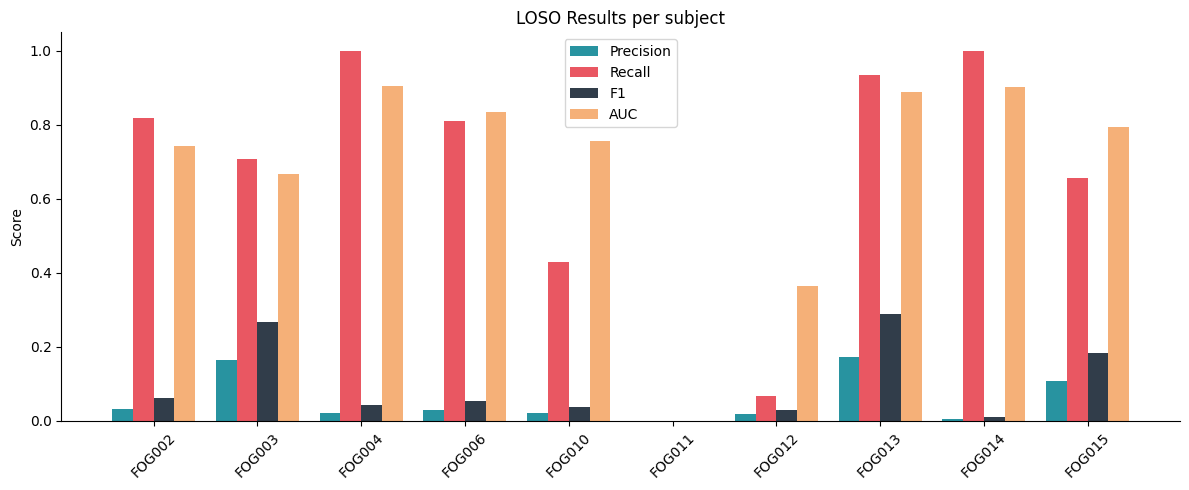

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_results))
w = 0.2

for i, (col, color, label) in enumerate([
    ('precision', '#028090', 'Precision'),
    ('recall',    '#E63946', 'Recall'),
    ('f1',        '#0D1B2A', 'F1'),
    ('auc',       '#F4A261', 'AUC'),
]):
    ax.bar(x + i*w, df_results[col], w, label=label, color=color, alpha=0.85)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(df_results['test_subject'], rotation=45)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('LOSO Results per subject')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('loso_results.png', dpi=150)
plt.show()

In [42]:
# Run inference only using saved models (no retraining needed)
for test_sub in test_subjects:
    # Load data
    X_test, y_test = segment(subject_data[test_sub])
    test_loader = DataLoader(FOGDataset(X_test, y_test), batch_size=256, shuffle=False)

    # Load saved model
    cfg   = INPUT_CONFIG[INPUT_MODE]
    model = MultiBranchCNN(ankle_ch=cfg['ankle_ch'], back_ch=cfg['back_ch']).to(DEVICE)
    model.load_state_dict(torch.load(f'model_LOSO_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.pth',
                                      map_location=DEVICE))
    model.eval()

    # Inference
    probs, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch.to(DEVICE)).squeeze().cpu()
            probs.extend(torch.sigmoid(logits).numpy())
            targets.extend(y_batch.numpy())

    probs   = np.array(probs)
    targets = np.array(targets)

    # Save
    np.save(f'probs_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy', probs)
    np.save(f'targets_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy', targets)
    print(f'{test_sub} done — {len(probs)} windows')

FOG002 done — 4115 windows
FOG003 done — 5744 windows
FOG004 done — 2085 windows
FOG006 done — 4579 windows
FOG010 done — 3071 windows
FOG011 done — 3885 windows
FOG012 done — 2474 windows
FOG013 done — 4350 windows
FOG014 done — 4861 windows
FOG015 done — 2880 windows


In [44]:
print(EXPERIMENT_NAME, 'inference complete')

no_aug inference complete


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score
from torch.utils.data import DataLoader

# For each subject, reload data keeping task_name, run inference, then analyze by task
task_results = []

for test_sub in test_subjects:
    # Load raw combined df (with task_name column)
    mapping = DEVICE_MAPPING[test_sub]
    df = load_subject(test_sub)  # already loaded in subject_data but without task_name
    
    # Reload with task_name — use ankle_l device as reference
    dev = mapping['ankle_l']
    df_raw = pd.read_csv(DATA_DIR / f'IMU_{dev}_{test_sub}_all_tasks.csv')
    
    # Load saved probs and targets
    probs   = np.load(f'probs_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy')
    targets = np.load(f'targets_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy')
    
    # Rebuild window-level task labels (same segmentation as training)
    feat_cols = get_feature_cols()
    df_combined = subject_data[test_sub]
    
    # Get task name per window
    task_labels_raw = df_combined['task_name'].values if 'task_name' in df_combined.columns else None
    
    if task_labels_raw is None:
        # Re-add task_name from the raw file
        ankle_l_df = pd.read_csv(DATA_DIR / f'IMU_{mapping["ankle_l"]}_{test_sub}.csv')
        min_len = len(subject_data[test_sub])
        task_labels_raw = ankle_l_df['task_name'].values[:min_len]
    
    # Segment task names with same window/step
    window_tasks = []
    for i in range(0, len(task_labels_raw) - WIN_SIZE, STEP):
        window_task = pd.Series(task_labels_raw[i:i+WIN_SIZE]).mode()[0]
        window_tasks.append(window_task)
    window_tasks = np.array(window_tasks[:len(probs)])
    
    # Analyze per task
    for task in np.unique(window_tasks):
        mask = window_tasks == task
        if mask.sum() < 10 or targets[mask].sum() == 0:
            continue  # skip tasks with too few windows or no FOG
        try:
            auc  = roc_auc_score(targets[mask], probs[mask])
            preds = (probs[mask] >= 0.5).astype(int)
            f1   = f1_score(targets[mask], preds, zero_division=0)
            fog_pct = 100 * targets[mask].mean()
            task_results.append({
                'subject': test_sub,
                'task':    task,
                'n_windows': int(mask.sum()),
                'fog_pct':   round(fog_pct, 2),
                'auc':       round(auc, 3),
                'f1':        round(f1, 3),
            })
        except:
            pass

df_task = pd.DataFrame(task_results)
print(df_task.to_string(index=False))

  [FOG002] task filter: 347625 → 205950 samples (59%)
  [FOG003] task filter: 463032 → 287388 samples (62%)
  [FOG004] task filter: 209980 → 104403 samples (50%)
  [FOG006] task filter: 334975 → 229124 samples (68%)
  [FOG010] task filter: 234090 → 153734 samples (66%)
  [FOG011] task filter: 271405 → 194433 samples (72%)
  [FOG012] task filter: 189237 → 123853 samples (65%)
  [FOG013] task filter: 395528 → 217685 samples (55%)
  [FOG014] task filter: 362495 → 243204 samples (67%)
  [FOG015] task filter: 270137 → 144172 samples (53%)
subject              task  n_windows  fog_pct   auc    f1
 FOG002 8_Shape_Circuit_1       2129     2.16 0.710 0.067
 FOG002 Narrow_Corridor_1       1986     1.01 0.766 0.056
 FOG003 8_Shape_Circuit_1       2902    13.09 0.643 0.283
 FOG003 Narrow_Corridor_1       2842     9.32 0.696 0.248
 FOG004 Narrow_Corridor_1       2085     0.58 0.905 0.043
 FOG006 8_Shape_Circuit_1       2339     1.45 0.832 0.083
 FOG006 Narrow_Corridor_1       2240     0.36 0.865 0.

In [46]:
def smooth_predictions(probs, window_size=5, threshold=0.5):
    """Flag as FOG only if majority of consecutive windows exceed threshold."""
    from scipy.ndimage import uniform_filter1d
    smoothed = uniform_filter1d(probs, size=window_size)
    return (smoothed >= threshold).astype(int)

In [47]:
def min_duration_filter(preds, min_windows=8):
    """Remove predicted FOG episodes shorter than min_windows consecutive windows."""
    from itertools import groupby
    result = preds.copy()
    i = 0
    for val, group in groupby(preds):
        length = len(list(group))
        if val == 1 and length < min_windows:
            result[i:i+length] = 0
        i += length
    return result

In [48]:
THRESHOLD = 0.5  # try 0.2, 0.3, 0.4 and see which gives best F1

In [49]:
def postprocess(probs, smooth_size=5, threshold=0.3, min_dur=4):
    smoothed = uniform_filter1d(probs, size=smooth_size)
    preds    = (smoothed >= threshold).astype(int)
    return min_duration_filter(preds, min_windows=min_dur)

In [51]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
from scipy.ndimage import uniform_filter1d

def min_duration_filter(preds, min_windows=4):
    from itertools import groupby
    result = preds.copy()
    i = 0
    for val, group in groupby(preds):
        length = len(list(group))
        if val == 1 and length < min_windows:
            result[i:i+length] = 0
        i += length
    return result

results = []
for smooth in [1, 3, 5, 7]:
    for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
        for min_dur in [1, 3, 5, 8]:
            all_p, all_t = [], []
            for test_sub in test_subjects:
                p = np.load(f'probs_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy')
                t = np.load(f'targets_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy')

                p_smooth = uniform_filter1d(p, size=smooth)
                preds    = (p_smooth >= thresh).astype(int)
                preds    = min_duration_filter(preds, min_windows=min_dur)
                all_p.extend(preds)
                all_t.extend(t)
            all_p = np.array(all_p)
            all_t = np.array(all_t)
            f1   = f1_score(all_t, all_p, zero_division=0)
            prec = precision_score(all_t, all_p, zero_division=0)
            rec  = recall_score(all_t, all_p, zero_division=0)
            results.append({
                'smooth': smooth, 'threshold': thresh, 'min_dur': min_dur,
                'f1': f1, 'precision': prec, 'recall': rec
            })

df_pp = pd.DataFrame(results).sort_values('f1', ascending=False)
print("Top 10 post-processing combinations:")
print(df_pp.head(10).to_string(index=False))

Top 10 post-processing combinations:
 smooth  threshold  min_dur       f1  precision   recall
      1        0.5        8 0.166811   0.098468 0.545234
      3        0.5        8 0.156572   0.089217 0.638934
      5        0.5        8 0.155748   0.088264 0.661551
      1        0.5        5 0.155072   0.088762 0.613086
      7        0.5        8 0.153803   0.086906 0.668013
      7        0.5        5 0.145889   0.081708 0.680129
      5        0.5        5 0.144553   0.080963 0.673667
      1        0.5        3 0.144144   0.081119 0.646204
      3        0.5        5 0.143974   0.080887 0.654281
      7        0.5        3 0.143243   0.079985 0.684976


In [52]:
from scipy.ndimage import uniform_filter1d
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

def prob_smoothing(probs, window=5, threshold=0.3):
    """Average probabilities over window then threshold."""
    smoothed = uniform_filter1d(probs.astype(float), size=window)
    return smoothed, (smoothed >= threshold).astype(int)

def majority_voting(probs, window=5, threshold=0.5, vote_frac=0.5):
    """Require vote_frac fraction of windows in sliding window to exceed threshold."""
    binary = (probs >= threshold).astype(float)
    votes  = uniform_filter1d(binary, size=window)
    return votes, (votes >= vote_frac).astype(int)

# Compare both methods across all subjects
print(f"{'Method':25} | {'Smooth/Vote':>10} | {'Thresh':>6} | {'Precision':>9} | {'Recall':>9} | {'F1':>8}")
print('-' * 80)

for method_name, method_fn, params in [
    ('No post-processing',    None,            [(1, 0.5)]),
    ('Prob smoothing',        prob_smoothing,  [(3, 0.2), (5, 0.2), (7, 0.2), (5, 0.3)]),
    ('Majority voting',       majority_voting, [(3, 0.5), (5, 0.5), (7, 0.5), (5, 0.6)]),
]:
    for window, thresh in params:
        all_preds, all_targets = [], []
        for test_sub in test_subjects:
            try:
                p = np.load(f'probs_{test_sub}_acc_no_aug.npy')
                t = np.load(f'targets_{test_sub}_acc_no_aug.npy')
                if method_fn is None:
                    preds = (p >= thresh).astype(int)
                else:
                    _, preds = method_fn(p, window=window, threshold=thresh)
                all_preds.extend(preds)
                all_targets.extend(t)
            except:
                pass
        all_preds   = np.array(all_preds)
        all_targets = np.array(all_targets)
        prec = precision_score(all_targets, all_preds, zero_division=0)
        rec  = recall_score(all_targets, all_preds, zero_division=0)
        f1   = f1_score(all_targets, all_preds, zero_division=0)
        print(f'{method_name:25} | {window:>10} | {thresh:>6.1f} | {prec:>9.3f} | {rec:>9.3f} | {f1:>8.3f}')
    print()

Method                    | Smooth/Vote | Thresh | Precision |    Recall |       F1
--------------------------------------------------------------------------------
No post-processing        |          1 |    0.5 |     0.070 |     0.688 |    0.127

Prob smoothing            |          3 |    0.2 |     0.041 |     0.913 |    0.078
Prob smoothing            |          5 |    0.2 |     0.041 |     0.926 |    0.079
Prob smoothing            |          7 |    0.2 |     0.041 |     0.932 |    0.078
Prob smoothing            |          5 |    0.3 |     0.045 |     0.877 |    0.085

Majority voting           |          3 |    0.5 |     0.073 |     0.700 |    0.132
Majority voting           |          5 |    0.5 |     0.075 |     0.698 |    0.135
Majority voting           |          7 |    0.5 |     0.077 |     0.700 |    0.138
Majority voting           |          5 |    0.6 |     0.116 |     0.578 |    0.193



In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
from scipy.ndimage import uniform_filter1d

TASKS_OF_INTEREST = {'8_Shape_Circuit_1', 'Narrow_Corridor_1'}


def majority_voting(probs, window=5, threshold=0.5, vote_frac=0.6):
    """Require vote_frac fraction of windows in sliding window to exceed threshold."""
    binary = (probs >= threshold).astype(float)
    votes  = uniform_filter1d(binary, size=window)
    return (votes >= vote_frac).astype(int)

def min_duration_filter(preds, min_windows=3):
    """Remove predicted FOG episodes shorter than min_windows consecutive windows."""
    from itertools import groupby
    result = preds.copy()
    i = 0
    for val, group in groupby(preds):
        length = len(list(group))
        if val == 1 and length < min_windows:
            result[i:i+length] = 0
        i += length
    return result

def postprocess(probs, window=5, threshold=0.5, vote_frac=0.6, min_dur=3):
    """Full post-processing pipeline : majority vote then minimum duration."""
    preds = majority_voting(probs, window=window, threshold=threshold, vote_frac=vote_frac)
    preds = min_duration_filter(preds, min_windows=min_dur)
    return preds

# ── Pre-load and mask once per subject ──────────────────────────
subject_probs   = {}
subject_targets = {}

for test_sub in test_subjects:
    p = np.load(f'probs_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy')
    t = np.load(f'targets_{test_sub}_{INPUT_MODE}_{EXPERIMENT_NAME}.npy')

    df_combined     = subject_data[test_sub]
    task_labels_raw = df_combined['task_name'].values

    window_tasks = []
    for i in range(0, len(task_labels_raw) - WIN_SIZE, STEP):
        window_tasks.append(pd.Series(task_labels_raw[i:i+WIN_SIZE]).mode()[0])
    window_tasks = np.array(window_tasks[:len(p)])

    mask = np.isin(window_tasks, list(TASKS_OF_INTEREST))
    subject_probs[test_sub]   = p[mask]
    subject_targets[test_sub] = t[mask]
    print(f'{test_sub}: {mask.sum()} windows | FOG: {t[mask].sum():.0f} ({100*t[mask].mean():.1f}%)')

# ── Grid search ─────────────────────────────────────────────────
results = []

for window in [3, 5, 7, 9]:
    for threshold in [0.4, 0.5, 0.6]:
        for vote_frac in [0.5, 0.6, 0.7, 0.8]:
            for min_dur in [1, 3, 5, 8]:
                all_p, all_t = [], []
                for test_sub in test_subjects:
                    p     = subject_probs[test_sub]
                    t     = subject_targets[test_sub]
                    preds = postprocess(p, window=window, threshold=threshold,
                                       vote_frac=vote_frac, min_dur=min_dur)
                    all_p.extend(preds)
                    all_t.extend(t)

                all_p = np.array(all_p)
                all_t = np.array(all_t)
                results.append({
                    'window'   : window,
                    'threshold': threshold,
                    'vote_frac': vote_frac,
                    'min_dur'  : min_dur,
                    'f1'       : round(f1_score(all_t, all_p, zero_division=0), 3),
                    'precision': round(precision_score(all_t, all_p, zero_division=0), 3),
                    'recall'   : round(recall_score(all_t, all_p, zero_division=0), 3),
                })

df_pp = pd.DataFrame(results).sort_values('f1', ascending=False)

print("\nTop 15 post-processing combinations (majority vote + min duration):")
print(df_pp.head(15).to_string(index=False))

# ── Best combination ─────────────────────────────────────────────
best = df_pp.iloc[0]
print(f"\n✓ Best combination:")
print(f"  window={int(best.window)} | threshold={best.threshold} | "
      f"vote_frac={best.vote_frac} | min_dur={int(best.min_dur)}")
print(f"  F1={best.f1:.3f} | Precision={best.precision:.3f} | Recall={best.recall:.3f}")

# ── Per subject results with best params ────────────────────────
print(f"\nPer subject results with best post-processing:")
print(f"{'Subject':>10} | {'FOG windows':>11} | {'Precision':>9} | {'Recall':>9} | {'F1':>8}")
print('-' * 60)

for test_sub in test_subjects:
    p     = subject_probs[test_sub]
    t     = subject_targets[test_sub]
    preds = postprocess(p,
                        window=int(best.window),
                        threshold=best.threshold,
                        vote_frac=best.vote_frac,
                        min_dur=int(best.min_dur))
    prec = precision_score(t, preds, zero_division=0)
    rec  = recall_score(t, preds, zero_division=0)
    f1   = f1_score(t, preds, zero_division=0)
    print(f'{test_sub:>10} | {int(t.sum()):>11} | {prec:>9.3f} | {rec:>9.3f} | {f1:>8.3f}')

FOG002: 4115 windows | FOG: 66 (1.6%)
FOG003: 5744 windows | FOG: 645 (11.2%)
FOG004: 2085 windows | FOG: 12 (0.6%)
FOG006: 4579 windows | FOG: 42 (0.9%)
FOG010: 3071 windows | FOG: 21 (0.7%)
FOG011: 3885 windows | FOG: 0 (0.0%)
FOG012: 2474 windows | FOG: 120 (4.9%)
FOG013: 4350 windows | FOG: 211 (4.9%)
FOG014: 4861 windows | FOG: 8 (0.2%)
FOG015: 2880 windows | FOG: 113 (3.9%)

Top 15 post-processing combinations (majority vote + min duration):
 window  threshold  vote_frac  min_dur    f1  precision  recall
      9        0.6        0.7        8 0.238      0.169   0.402
      9        0.6        0.6        8 0.238      0.156   0.503
      7        0.6        0.7        8 0.233      0.155   0.471
      7        0.6        0.6        8 0.233      0.155   0.471
      9        0.6        0.6        5 0.229      0.148   0.511
      9        0.6        0.5        8 0.229      0.143   0.581
      7        0.6        0.5        8 0.229      0.143   0.569
      3        0.6        0.5       

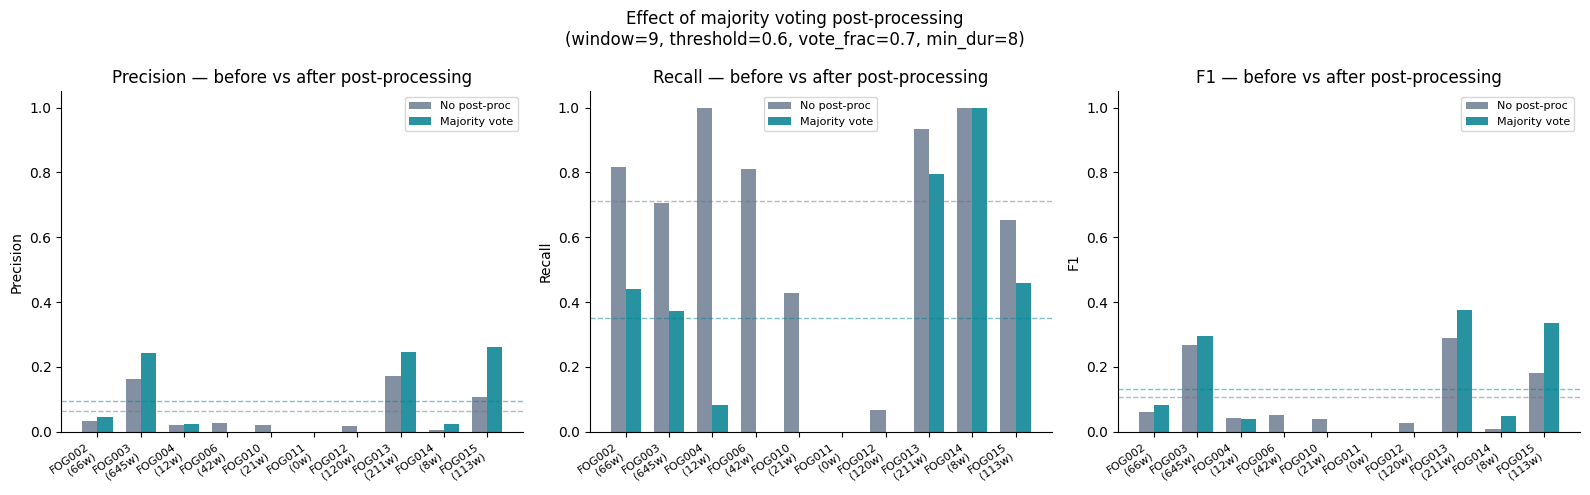

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('f1',        'F1')
]

subjects    = list(test_subjects)
fog_windows = [66, 645, 12, 42, 21, 0, 120, 211, 8, 113]

for ax, (metric, title) in zip(axes, metrics):
    before_vals, after_vals = [], []
    for test_sub in test_subjects:
        p = subject_probs[test_sub]
        t = subject_targets[test_sub]
        preds_before = (p >= 0.5).astype(int)
        preds_after  = postprocess(p, window=9, threshold=0.6, vote_frac=0.7, min_dur=8)
        fn = {'precision': precision_score, 'recall': recall_score, 'f1': f1_score}[metric]
        before_vals.append(fn(t, preds_before, zero_division=0))
        after_vals.append(fn(t, preds_after,   zero_division=0))

    x = np.arange(len(subjects))
    w = 0.35
    bars1 = ax.bar(x - w/2, before_vals, w, label='No post-proc', color='#64748B', alpha=0.8)
    bars2 = ax.bar(x + w/2, after_vals,  w, label='Majority vote', color='#028090', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s}\n({fw}w)' for s, fw in zip(subjects, fog_windows)],
                       rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(title)
    ax.set_title(f'{title} — before vs after post-processing')
    ax.set_ylim(0, 1.05)
    ax.axhline(np.mean([v for v, fw in zip(before_vals, fog_windows) if fw > 0]),
               color='#64748B', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(np.mean([v for v, fw in zip(after_vals, fog_windows) if fw > 0]),
               color='#028090', linestyle='--', linewidth=1, alpha=0.5)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Effect of majority voting post-processing\n'
             '(window=9, threshold=0.6, vote_frac=0.7, min_dur=8)',
             fontsize=12)
plt.tight_layout()
plt.savefig('before_after_postprocessing.png', dpi=150)
plt.show()

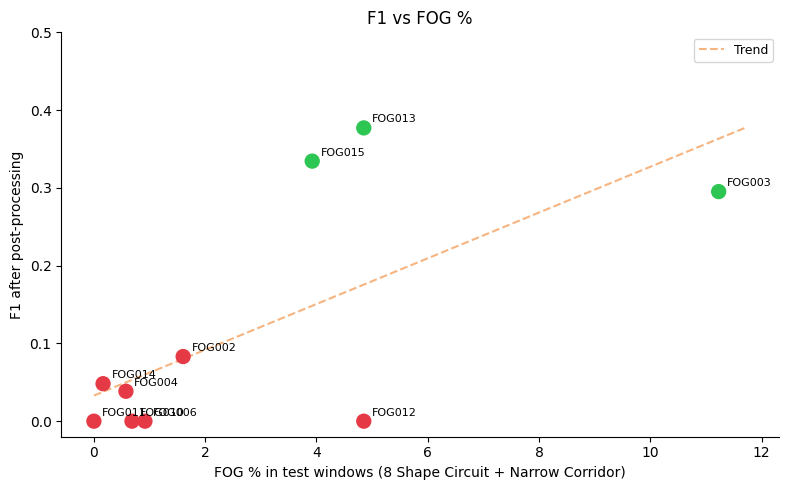

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))

f1_after  = []
fog_pcts  = []
for test_sub in test_subjects:
    p = subject_probs[test_sub]
    t = subject_targets[test_sub]
    preds = postprocess(p, window=9, threshold=0.6, vote_frac=0.7, min_dur=8)
    f1_after.append(f1_score(t, preds, zero_division=0))
    fog_pcts.append(100 * t.mean())

colors = ['#E63946' if f < 0.1 else '#028090' if f < 0.25 else '#2DC653' for f in f1_after]
ax.scatter(fog_pcts, f1_after, s=100, c=colors, zorder=3)
for i, sub in enumerate(test_subjects):
    ax.annotate(sub, (fog_pcts[i], f1_after[i]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

# Trend line
if len(fog_pcts) > 2:
    z = np.polyfit(fog_pcts, f1_after, 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(0, max(fog_pcts)+0.5, 100)
    ax.plot(x_line, p_line(x_line), '--', color='#F4A261', alpha=0.8, label='Trend')

ax.set_xlabel('FOG % in test windows (8 Shape Circuit + Narrow Corridor)')
ax.set_ylabel('F1 after post-processing')
ax.set_title('F1 vs FOG %')
ax.set_ylim(-0.02, 0.5)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('f1_vs_fog_pct.png', dpi=150)
plt.show()

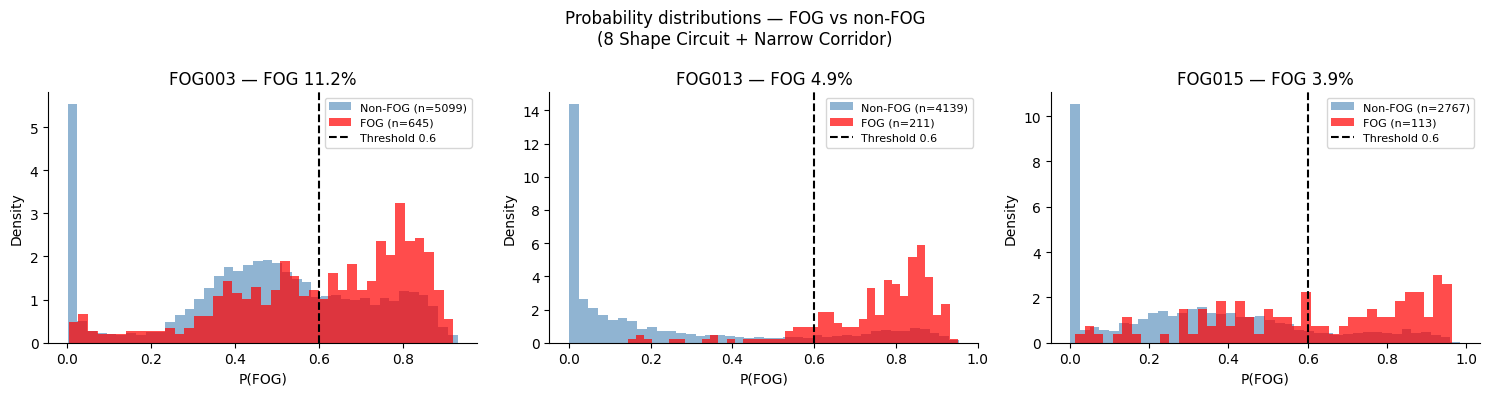

In [60]:
# Show 3 representative subjects: best (FOG013), medium (FOG003), worst (FOG012)
selected = ['FOG003', 'FOG013', 'FOG015']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, sub in zip(axes, selected):
    p = subject_probs[sub]
    t = subject_targets[sub]

    ax.hist(p[t==0], bins=40, alpha=0.6, color='steelblue',
            label=f'Non-FOG (n={int((t==0).sum())})', density=True)
    ax.hist(p[t==1], bins=40, alpha=0.7, color='red',
            label=f'FOG (n={int(t.sum())})', density=True)
    ax.axvline(0.6, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.6')
    ax.set_xlabel('P(FOG)')
    ax.set_ylabel('Density')
    ax.set_title(f'{sub} — FOG {100*t.mean():.1f}%')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Probability distributions — FOG vs non-FOG\n'
             '(8 Shape Circuit + Narrow Corridor)', fontsize=12)
plt.tight_layout()
plt.savefig('prob_distributions_selected.png', dpi=150)
plt.show()

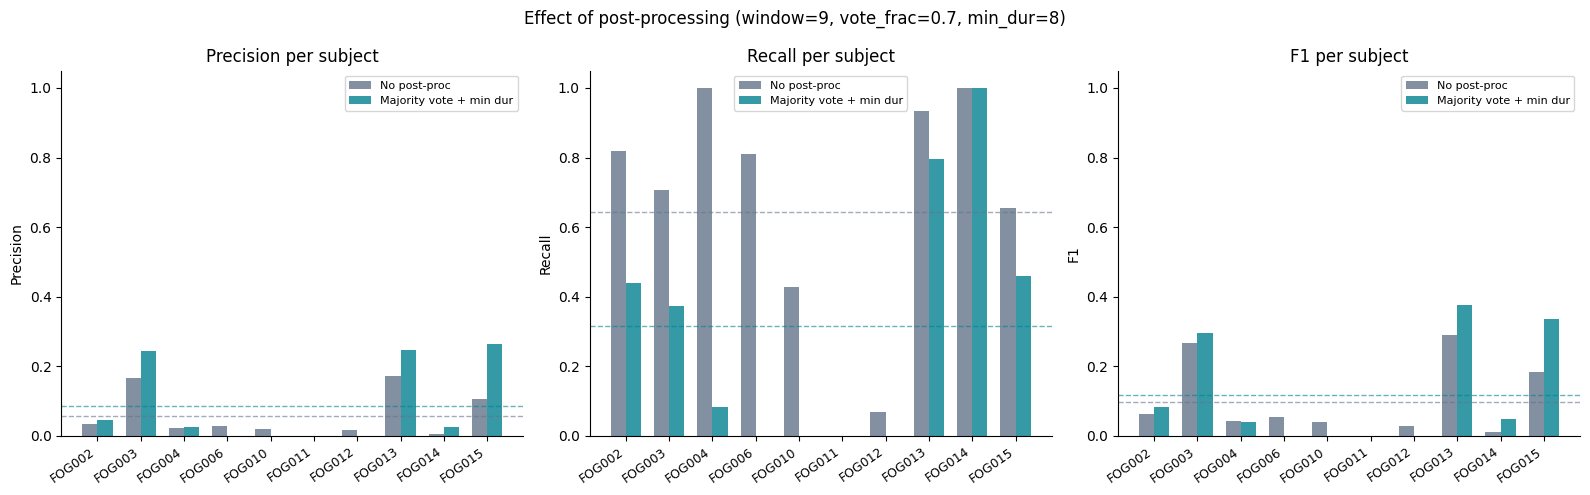

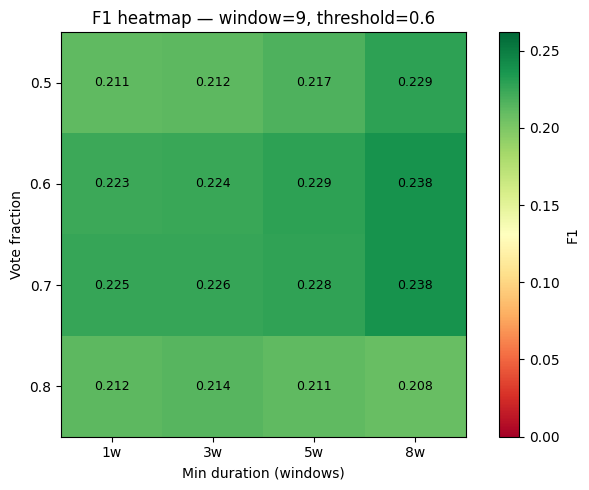

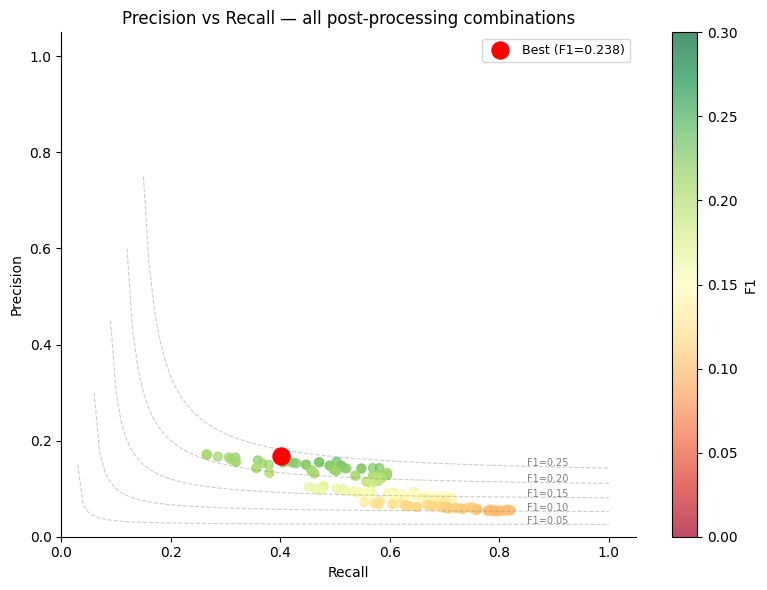

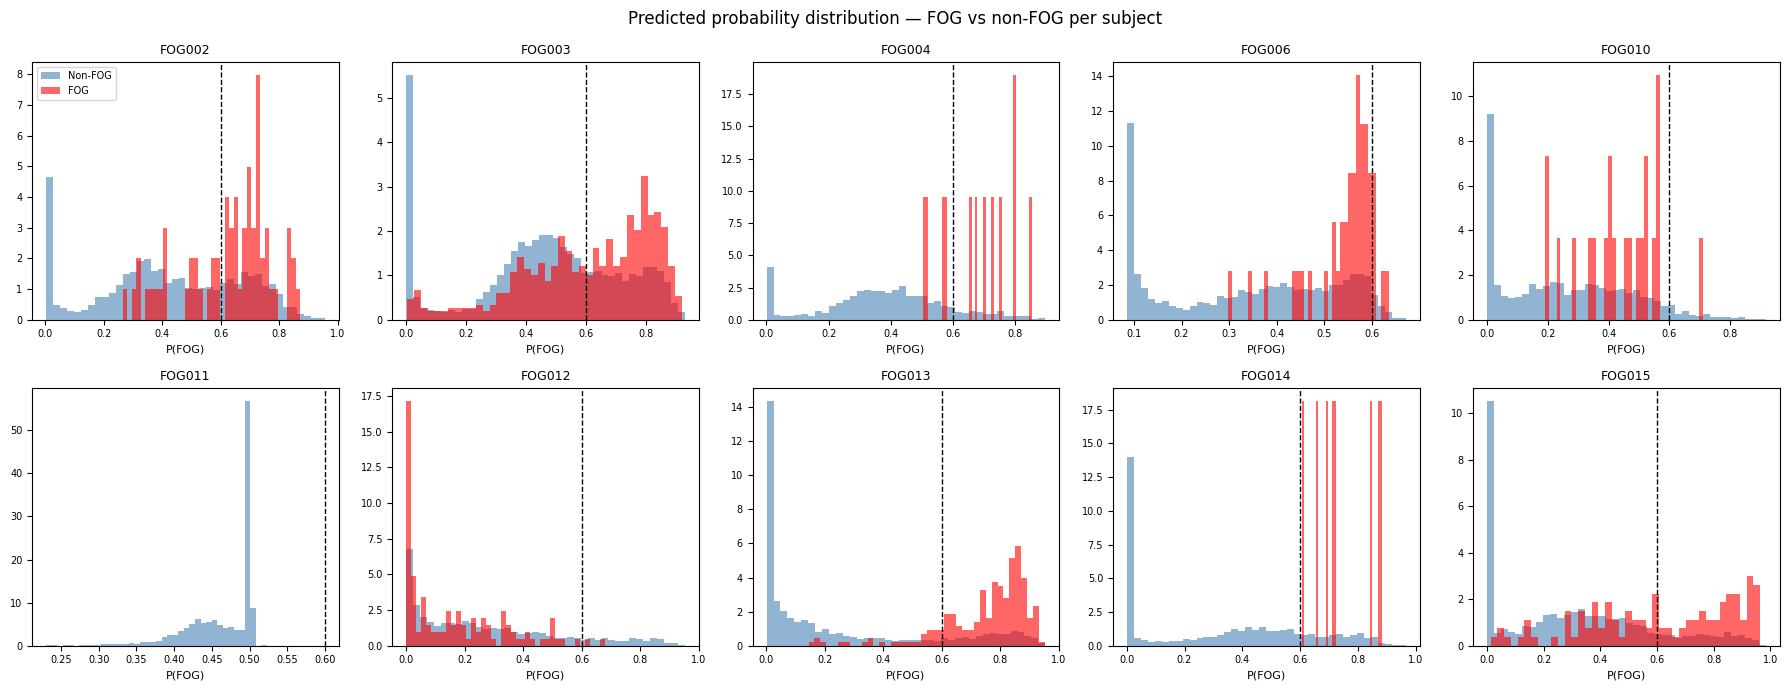

In [67]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# ── 1. Before vs After post-processing per subject ──────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics   = ['precision', 'recall', 'f1']
titles    = ['Precision', 'Recall', 'F1']
colors    = {'before': '#64748B', 'after': '#028090'}

for ax, metric, title in zip(axes, metrics, titles):
    before_vals, after_vals = [], []

    for test_sub in test_subjects:
        p = subject_probs[test_sub]
        t = subject_targets[test_sub]

        # Before — raw threshold 0.5
        preds_before = (p >= 0.5).astype(int)
        # After — best post-processing
        preds_after  = postprocess(p,
                                   window=int(best.window),
                                   threshold=best.threshold,
                                   vote_frac=best.vote_frac,
                                   min_dur=int(best.min_dur))

        fn = {'precision': precision_score,
              'recall':    recall_score,
              'f1':        f1_score}[metric]
        before_vals.append(fn(t, preds_before, zero_division=0))
        after_vals.append(fn(t, preds_after,   zero_division=0))

    x = np.arange(len(test_subjects))
    w = 0.35
    ax.bar(x - w/2, before_vals, w, label='No post-proc', color=colors['before'], alpha=0.8)
    ax.bar(x + w/2, after_vals,  w, label='Majority vote + min dur', color=colors['after'], alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(test_subjects, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(f'{title} per subject')
    ax.set_ylim(0, 1.05)
    ax.axhline(np.mean(before_vals), color=colors['before'], linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(np.mean(after_vals),  color=colors['after'],  linestyle='--', linewidth=1, alpha=0.6)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(f'Effect of post-processing (window={int(best.window)}, '
             f'vote_frac={best.vote_frac}, min_dur={int(best.min_dur)})',
             fontsize=12)
plt.tight_layout()
plt.savefig('postprocessing_comparison.png', dpi=150)
plt.show()


# ── 2. Precision-Recall trade-off heatmap ───────────────────────
# Show F1 as heatmap over vote_frac × min_dur (fixed best window and threshold)
pivot_data = df_pp[
    (df_pp['window']    == int(best.window)) &
    (df_pp['threshold'] == best.threshold)
].pivot_table(index='vote_frac', columns='min_dur', values='f1')

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot_data.values, cmap='RdYlGn', vmin=0, vmax=pivot_data.values.max()*1.1)
ax.set_xticks(range(len(pivot_data.columns)))
ax.set_yticks(range(len(pivot_data.index)))
ax.set_xticklabels([f'{c}w' for c in pivot_data.columns])
ax.set_yticklabels([f'{r:.1f}' for r in pivot_data.index])
ax.set_xlabel('Min duration (windows)')
ax.set_ylabel('Vote fraction')
ax.set_title(f'F1 heatmap — window={int(best.window)}, threshold={best.threshold}')
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        val = pivot_data.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, color='white' if val < pivot_data.values.max()*0.7 else 'black')
plt.colorbar(im, ax=ax, label='F1')
plt.tight_layout()
plt.savefig('postprocessing_heatmap.png', dpi=150)
plt.show()


# ── 3. Precision vs Recall scatter — all combinations ───────────
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df_pp['recall'], df_pp['precision'],
                     c=df_pp['f1'], cmap='RdYlGn',
                     s=40, alpha=0.7, vmin=0, vmax=0.3)
# Highlight best
ax.scatter(best.recall, best.precision, s=150, color='red',
           zorder=5, label=f'Best (F1={best.f1:.3f})')
# F1 iso-curves
for f1_val in [0.05, 0.10, 0.15, 0.20, 0.25]:
    r = np.linspace(0.01, 1.0, 100)
    p = f1_val * r / (2*r - f1_val)
    p = np.where((p > 0) & (p <= 1), p, np.nan)
    ax.plot(r, p, '--', color='gray', alpha=0.4, linewidth=0.8)
    idx = np.nanargmin(np.abs(r - 0.85))
    if not np.isnan(p[idx]):
        ax.text(r[idx], p[idx], f'F1={f1_val:.2f}', fontsize=7, color='gray')
plt.colorbar(scatter, ax=ax, label='F1')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall — all post-processing combinations')
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('precision_recall_scatter.png', dpi=150)
plt.show()


# ── 4. Probability distributions FOG vs non-FOG ─────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes = axes.flatten()

for ax, test_sub in zip(axes, test_subjects):
    p = subject_probs[test_sub]
    t = subject_targets[test_sub]

    ax.hist(p[t==0], bins=40, alpha=0.6, color='steelblue',
            label='Non-FOG', density=True)
    ax.hist(p[t==1], bins=40, alpha=0.6, color='red',
            label='FOG', density=True)
    ax.axvline(best.threshold, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{test_sub}', fontsize=9)
    ax.set_xlabel('P(FOG)', fontsize=8)
    ax.tick_params(labelsize=7)
    if test_sub == test_subjects[0]:
        ax.legend(fontsize=7)

plt.suptitle('Predicted probability distribution — FOG vs non-FOG per subject', fontsize=12)
plt.tight_layout()
plt.savefig('prob_distributions.png', dpi=150)
plt.show()

Variance explained: 6.76%


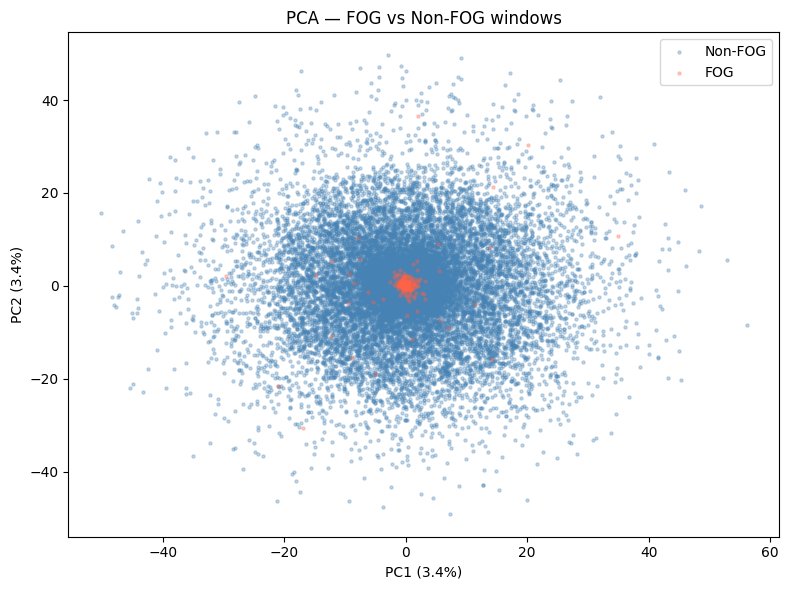

In [63]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Stack all subjects
X_all, y_all, sub_all = [], [], []
for sub in test_subjects:
    df = subject_data[sub]
    feat_cols = get_feature_cols()
    X = df[feat_cols].values
    y = df['fog'].values  # or however FOG label is stored
    
    # Segment into windows (same as training)
    for i in range(0, len(X) - WIN_SIZE, STEP):
        X_all.append(X[i:i+WIN_SIZE].flatten())
        y_all.append(pd.Series(y[i:i+WIN_SIZE]).mode()[0])
        sub_all.append(sub)

X_all = np.array(X_all)
y_all = np.array(y_all)

# PCA
X_scaled = StandardScaler().fit_transform(X_all)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
print(f'Variance explained: {pca.explained_variance_ratio_.sum():.2%}')

plt.figure(figsize=(8, 6))
for label, color, name in [(0, 'steelblue', 'Non-FOG'), (1, 'tomato', 'FOG')]:
    mask = y_all == label
    plt.scatter(coords[mask, 0], coords[mask, 1], c=color, label=name, alpha=0.3, s=5)
plt.legend()
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA — FOG vs Non-FOG windows')
plt.tight_layout()
plt.show()

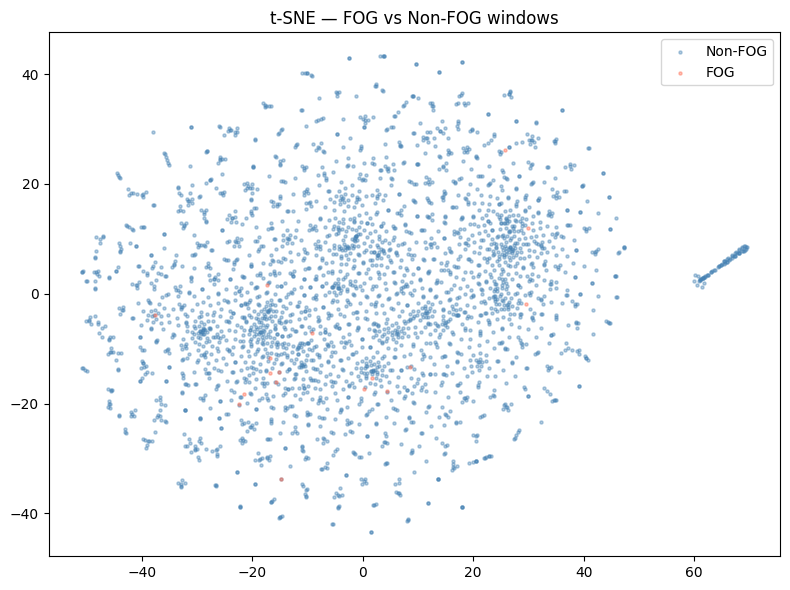

In [64]:
from sklearn.manifold import TSNE

# subsample — t-SNE is slow on >5k points
idx = np.random.choice(len(X_all), size=min(3000, len(X_all)), replace=False)
coords_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled[idx])

plt.figure(figsize=(8, 6))
for label, color, name in [(0, 'steelblue', 'Non-FOG'), (1, 'tomato', 'FOG')]:
    mask = y_all[idx] == label
    plt.scatter(coords_tsne[mask, 0], coords_tsne[mask, 1], c=color, label=name, alpha=0.4, s=5)
plt.legend()
plt.title('t-SNE — FOG vs Non-FOG windows')
plt.tight_layout()
plt.show()


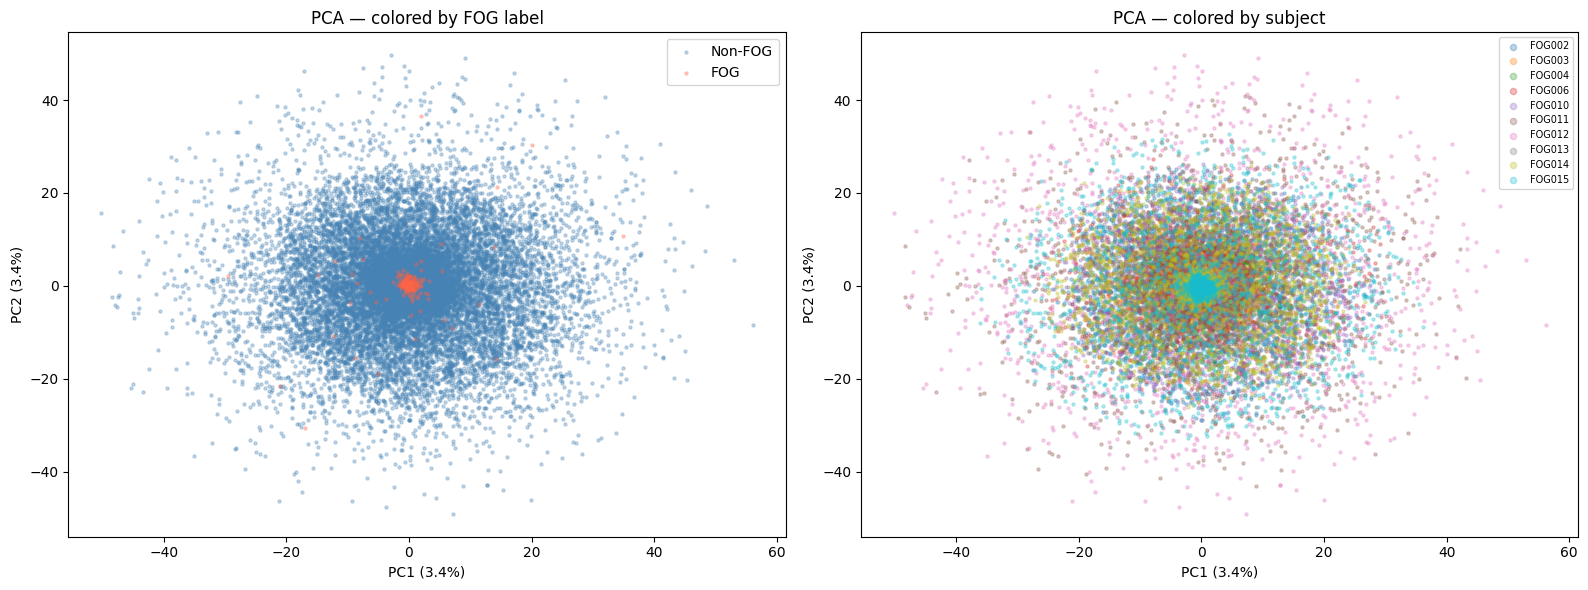

In [65]:
import matplotlib.cm as cm

subjects = np.array(sub_all)
unique_subs = np.unique(subjects)
colors = cm.tab10(np.linspace(0, 1, len(unique_subs)))
sub_to_color = {s: c for s, c in zip(unique_subs, colors)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: color by FOG label
for label, color, name in [(0, 'steelblue', 'Non-FOG'), (1, 'tomato', 'FOG')]:
    mask = y_all == label
    axes[0].scatter(coords[mask, 0], coords[mask, 1], c=color, label=name, alpha=0.3, s=5)
axes[0].legend()
axes[0].set_title('PCA — colored by FOG label')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Right: color by subject
for sub in unique_subs:
    mask = subjects == sub
    axes[1].scatter(coords[mask, 0], coords[mask, 1], c=[sub_to_color[sub]], label=sub, alpha=0.3, s=5)
axes[1].legend(markerscale=2, fontsize=7, loc='best')
axes[1].set_title('PCA — colored by subject')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.tight_layout()
plt.show()


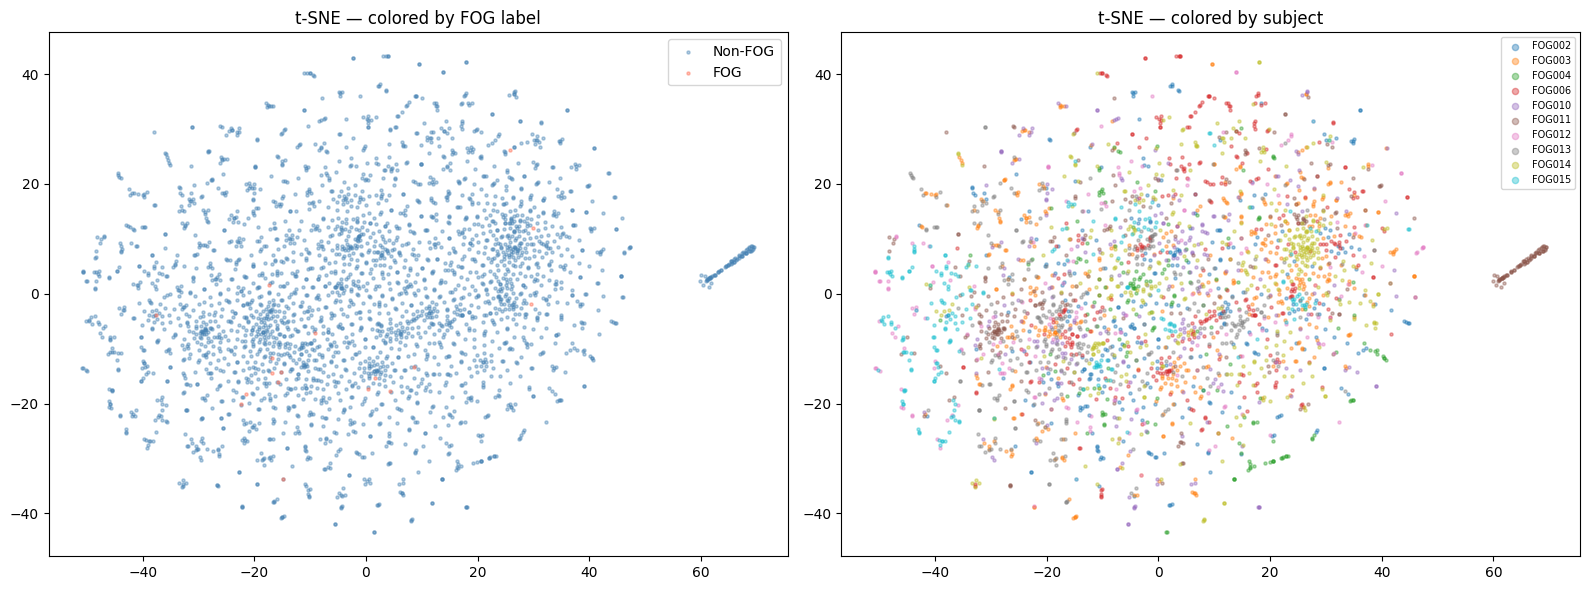

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: color by FOG label
for label, color, name in [(0, 'steelblue', 'Non-FOG'), (1, 'tomato', 'FOG')]:
    mask = y_all[idx] == label
    axes[0].scatter(coords_tsne[mask, 0], coords_tsne[mask, 1], c=color, label=name, alpha=0.4, s=5)
axes[0].legend()
axes[0].set_title('t-SNE — colored by FOG label')

# Right: color by subject
subjects_idx = subjects[idx]
for sub in unique_subs:
    mask = subjects_idx == sub
    axes[1].scatter(coords_tsne[mask, 0], coords_tsne[mask, 1], c=[sub_to_color[sub]], label=sub, alpha=0.4, s=5)
axes[1].legend(markerscale=2, fontsize=7, loc='best')
axes[1].set_title('t-SNE — colored by subject')

plt.tight_layout()
plt.show()

